## Low-rank solver

First approach of implementing a low-rank solver based om Burer Montiero factorization, i.e., assuming that $X = P Q^T$, where $P, Q$ are of shape $N \times r_s$ ($r_s$ is the rank)$ 

The problem with this method is slow and unstable convergence. Different regularization techniques are tried, like projecting $X$ s.t. its positive, TV-regularization, and a semi-convergent approach (Landweber iteration).

This method ended up not being used in the thesis, since the Dynamical Low-Rank scheme is more stable.

For the implementation, see `src/algorithms/weighted_low_rank_solver.py`.

---

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from fenics import *
from utils.colors import *
from utils.mesh_utils import get_square_f
from algorithms.weighted_low_rank_solver import WeightedLowRankSolver
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W, tikhonov_solver

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Problem setup
mesh = UnitSquareMesh(64, 64)
V_h = FunctionSpace(mesh, 'CG', 1)
rsvd = MatrixFreeRSVD(V_h)
x0, y0, width, height = 0.1, 0.7, 0.15, 0.15
f = get_square_f(V_h, x0, y0, w=width, h=height)
x = f.vector().get_local()
y = rsvd.apply_K(x)

In [3]:
# Approximate SVD K = U S V^T and weights W
Uk, Sk, VkT = rsvd.mf_rsvd(k=50)
w = get_approximate_W(VkT.T, rsvd.M_dx)

# Full-rank weighted tikhonov solution
solver = WeightedLowRankSolver(
    V_h=V_h,
    M_dx=rsvd.M_dx,
    M_ds=rsvd.M_ds,
    U=Uk,
    S=Sk,
    VT=VkT,
)
f_tikhonov = Function(V_h)
f_tikhonov.vector()[:] = tikhonov_solver(
    rsvd=rsvd,
    W_diag=w,
    y=y,
    lambda_=1e-4
)

# Low-rank weighted tikhonov solution
f_low_rank = solver.solve(y,
    r_s=1,
    w=w,
    alpha=0.2,     # step size
    lambda_=1e-6,  # regularization param
    max_iter=5000,
)

f_low_rank_adam = solver.solve_adam(
    y=y,
    r_s=1,
    w=w,
    lambda_=1e-6
)

[##############################] 5000/5000 (dX=1.5e-02)

[##############################] 5000/5000 (dX=2.3e-02)

Returning lowest error solution (iteration 4595)


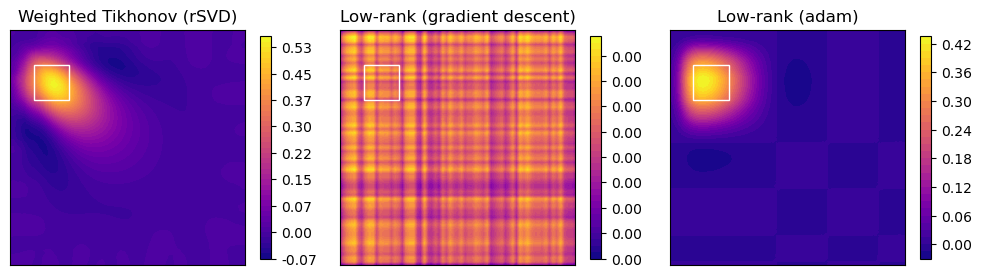

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

f_list = [f_tikhonov, f_low_rank, f_low_rank_adam]
titles = ['Weighted Tikhonov (rSVD)', 'Low-rank (gradient descent)', 'Low-rank (adam)']

for ax, f, t in zip(axes, f_list, titles):
    plt.sca(ax)
    p = plot(f, title=t, cmap=CMAP)
    square = patches.Rectangle((x0, y0), width, height, edgecolor='white', facecolor='none')
    ax.add_patch(square)
    fig.colorbar(p, ax=ax, format="%.2f", shrink=0.6)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [5]:
# Projected low-rank
f_low_rank_projected = solver.solve_adam(y,
    r_s=1,
    w=w,
    alpha=0.1,     # step size
    lambda_=1e-6,  # regularization param
    projection=True
)

# TV-regularization 
f_low_rank_TV = solver.solve_TV(
    y=y,
    r_s=1,
    w=w,
    lambda_=1e-4,
    beta=5e-8
)
# Semi-convergent approach
f_semi = solver.solve_semi(
    y=y,
    r_s=1,
    w=w
)

[###########                   ] 1875/5000 (dX=0.0e+00)
Converged at iteration 1875
Returning lowest error solution (iteration 1813)
[##############################] 5000/5000 (dX=1.5e-02)

Returning lowest error solution (iteration 505)
[##############################] 5000/5000 (dX=3.4e-02)

Returning lowest error solution (iteration 2065)


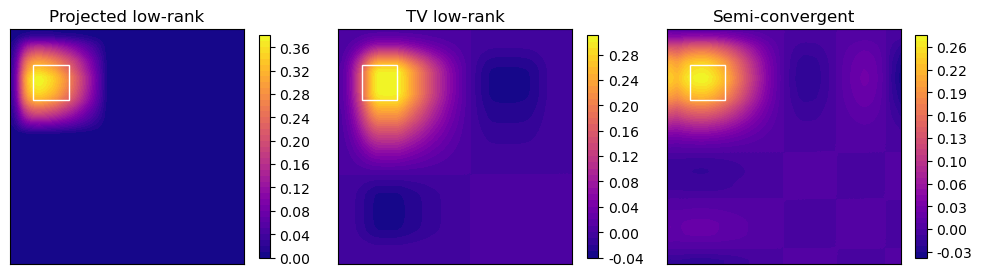

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

f_list = [f_low_rank_projected, f_low_rank_TV, f_semi]
titles = ['Projected low-rank', 'TV low-rank', 'Semi-convergent']

for ax, f, t in zip(axes, f_list, titles):
    plt.sca(ax)
    p = plot(f, title=t, cmap=CMAP)
    square = patches.Rectangle((x0, y0), width, height, edgecolor='white', facecolor='none')
    ax.add_patch(square)
    fig.colorbar(p, ax=ax, format="%.2f", shrink=0.6)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()